# 02 — SARIMA in detail

Deze notebook hoort bij [`docs/methodologie/sarima.md`](../docs/methodologie/sarima.md).
We doen vier dingen die de docs alleen *beschrijven*:

1. **Trainen + forecasten** op één opleiding/herkomst
2. **Prediction interval** plotten (80% en 95%) — wat de docs niet laten zien
3. **Forecast vs. realisatie** vergelijken — het echte testmoment
4. **Aannames concreet checken** (jaar-op-jaar correlatie, historie-lengte)

> 🎯 **Doel:** intuïtie voor *wat SARIMA leert* en *wanneer je het niet moet vertrouwen*.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


## 1. Wat is SARIMA — in gewoon Nederlands

Aanmelddata heeft twee karakteristieken die het lastig maken:

- **Sterke jaarlijkse seizoenscyclus** — weken 39–52 (zomer) zijn rustig, jan–mei is druk.
- **Sterke autocorrelatie** — week T lijkt sterk op week T-1.

SARIMA combineert beide expliciet:

$$\text{SARIMA}(p,d,q)(P,D,Q)_{52}$$

| Component | Wat doet het? | Wat betekent het hier? |
|-----------|---------------|------------------------|
| `p` (AR) | Autoregressie op de korte termijn | Hoe sterk hangt week T af van week T-1 |
| `d` (I)  | Differentiatie | Trend wegfilteren (in onze data: 0 → geen trend-diff) |
| `q` (MA) | Moving average van fouten | Verzacht ruis |
| `(P,D,Q)_{52}` | Hetzelfde, maar op de seizoens-lag van 52 weken | Vergelijk week T van dit jaar met week T van vorig jaar |

In de pipeline zijn deze ordes **vast** — `(1,0,1)(1,1,1,52)` voor het cumulatieve spoor.
Vrij vertaald: "kijk 1 week en 52 weken terug, doe één seizoens-differentiatie".


In [2]:
from studentprognose.utils.constants import (
    SARIMA_ORDER, SARIMA_SEASONAL_ORDER,
    SARIMA_ORDER_INDIVIDUAL, SARIMA_SEASONAL_ORDER_ALT,
)
print(f"Cumulatief spoor:    order={SARIMA_ORDER}, seasonal_order={SARIMA_SEASONAL_ORDER}")
print(f"Individueel (alt):   order={SARIMA_ORDER_INDIVIDUAL}, seasonal_order={SARIMA_SEASONAL_ORDER_ALT}")


Cumulatief spoor:    order=(1, 0, 1), seasonal_order=(1, 1, 1, 52)
Individueel (alt):   order=(1, 1, 1), seasonal_order=(1, 1, 0, 52)


In [3]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 2. Trainingsreeks bouwen + model fitten

We voorspellen 2023 vanaf peilweek 12 — zodat we straks kunnen vergelijken met de
**werkelijke realisatie** van wk 38 (einddeadline).


In [4]:
from studentprognose.models.sarima import _get_transformed_data, create_time_series
from studentprognose.utils.weeks import compute_pred_len, get_all_weeks_valid
from statsforecast.models import ARIMA

PROGRAMMA = "B Psychologie"
HERKOMST = "NL"
EXAMENTYPE = "Bachelor"
PREDICT_YEAR = 2023   # backtest: we hebben de realisatie van 2023
PREDICT_WEEK = 12

wide = _get_transformed_data(data_cumulative.copy(), min_training_year=2016)
subset = wide[
    (wide["Croho groepeernaam"] == PROGRAMMA)
    & (wide["Herkomst"] == HERKOMST)
    & (wide["Examentype"] == EXAMENTYPE)
    & (wide["Collegejaar"] <= PREDICT_YEAR)
].copy()
subset["39"] = 0
weekcols = get_all_weeks_valid(subset.columns)
pred_len = compute_pred_len(PREDICT_WEEK)
ts_data = create_time_series(subset, pred_len).astype(float)

print(f"Trainingsreeks: {ts_data.size} weken (~{ts_data.size / 52:.1f} academische jaren)")
print(f"Voorspelhorizon: {pred_len} weken (vanaf wk {PREDICT_WEEK + 1} t/m wk 38 van {PREDICT_YEAR})")


Trainingsreeks: 390 weken (~7.5 academische jaren)
Voorspelhorizon: 26 weken (vanaf wk 13 t/m wk 38 van 2023)


## 3. Model + prediction interval

We gebruiken `statsforecast.ARIMA` rechtstreeks (de zelfde backend als
`SARIMAForecaster`) om naast de puntvoorspelling ook 80% en 95% **prediction
intervals** te krijgen — een planner wil niet alleen "520 studenten" weten,
maar ook de plausibele bandbreedte.


In [5]:
model = ARIMA(order=SARIMA_ORDER, season_length=52, seasonal_order=SARIMA_SEASONAL_ORDER[:3])
model.fit(y=ts_data)
fc = model.predict(h=pred_len, level=[80, 95])

print(f"Forecast & intervallen voor wk {PREDICT_WEEK + 1} t/m wk 38 ({PREDICT_YEAR}):")
mean_arr = np.asarray(fc["mean"])
lo95 = np.asarray(fc["lo-95"])
hi95 = np.asarray(fc["hi-95"])
forecast_table = pd.DataFrame({
    "week": list(range(PREDICT_WEEK + 1, 39)),
    "voorspelling": mean_arr.round(1),
    "lo 95%": lo95.round(1),
    "hi 95%": hi95.round(1),
})
print(forecast_table.head(10).to_string(index=False))
print(f"...")
print(f"\nVoorspelling wk 38 (einddeadline): {mean_arr[-1]:.0f}  (95%-interval: [{lo95[-1]:.0f}, {hi95[-1]:.0f}])")


Forecast & intervallen voor wk 13 t/m wk 38 (2023):
 week  voorspelling  lo 95%  hi 95%
   13         160.6   147.5   173.7
   14         166.3   148.5   184.1
   15         186.8   165.6   208.0
   16         200.4   176.5   224.4
   17         216.9   190.7   243.1
   18         231.3   203.2   259.4
   19         250.3   220.5   280.1
   20         272.7   241.5   303.9
   21         289.3   256.7   321.8
   22         308.5   274.9   342.2
...

Voorspelling wk 38 (einddeadline): 545  (95%-interval: [502, 587])


## 4. Visualisatie + realisatie

We tekenen de trainingsreeks, de forecast, **de bandbreedte (80% en 95%)** én de
werkelijke wk-38 cumulatieve vooraanmelders uit hetzelfde collegejaar.

> ℹ️ **Let op:** SARIMA voorspelt de *aanmeldcurve* (gewogen vooraanmelders), niet
> direct het aantal *inschrijvingen*. De XGBoost regressor en het ensemble vertalen
> die curve in de uiteindelijke prognose voor het cohort — zie
> [`03_xgboost.ipynb`](03_xgboost.ipynb) en [`06_output_interpreteren.ipynb`](06_output_interpreteren.ipynb).


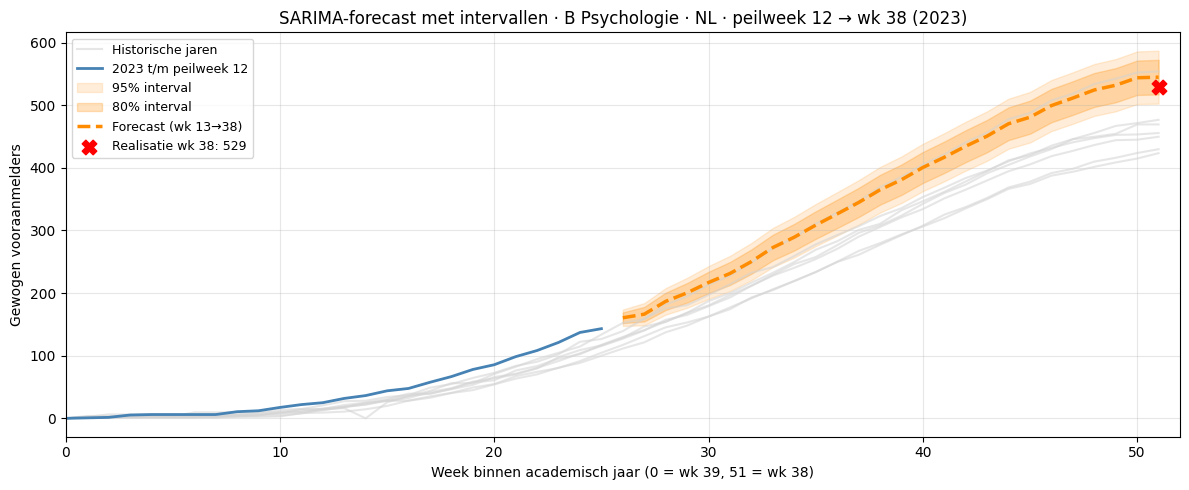


Forecast wk 38: 545 · Realisatie: 529 · Fout: +16 (+3.0%)


In [6]:
# Werkelijke gewogen vooraanmelders op week 38 van het voorspeljaar
werkelijk = data_cumulative[
    (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
    & (data_cumulative["Herkomst"] == HERKOMST)
    & (data_cumulative["Examentype"] == EXAMENTYPE)
    & (data_cumulative["Collegejaar"] == PREDICT_YEAR)
    & (data_cumulative["Weeknummer"] == 38)
]["Gewogen vooraanmelders"].sum()

n_full_years = ts_data.size // 52
remainder = ts_data.size - n_full_years * 52

fig, ax = plt.subplots(figsize=(12, 5))

# Historische jaren als achtergrond
for j in range(n_full_years):
    ax.plot(range(52), ts_data[j * 52 : (j + 1) * 52], color="lightgray", alpha=0.55,
            label="Historische jaren" if j == 0 else None)

# Huidige jaar tot peilweek
ax.plot(range(remainder), ts_data[n_full_years * 52 :],
        color="steelblue", linewidth=2,
        label=f"{PREDICT_YEAR} t/m peilweek {PREDICT_WEEK}")

# Forecast met bandbreedte
x_fc = range(remainder, remainder + len(fc["mean"]))
ax.fill_between(x_fc, fc["lo-95"], fc["hi-95"], alpha=0.15, color="darkorange", label="95% interval")
ax.fill_between(x_fc, fc["lo-80"], fc["hi-80"], alpha=0.25, color="darkorange", label="80% interval")
ax.plot(x_fc, fc["mean"], color="darkorange", linewidth=2.5, linestyle="--",
        label=f"Forecast (wk {PREDICT_WEEK + 1}→38)")

# Realisatie wk 38
if werkelijk > 0:
    ax.scatter([remainder + len(fc["mean"]) - 1], [werkelijk],
               color="red", s=110, zorder=10, marker="X",
               label=f"Realisatie wk 38: {werkelijk:.0f}")

ax.set_xlim(0, 52)
ax.set_xlabel("Week binnen academisch jaar (0 = wk 39, 51 = wk 38)")
ax.set_ylabel("Gewogen vooraanmelders")
ax.set_title(f"SARIMA-forecast met intervallen · {PROGRAMMA} · {HERKOMST} · peilweek {PREDICT_WEEK} → wk 38 ({PREDICT_YEAR})")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

if werkelijk > 0:
    fc_wk38 = float(fc["mean"][-1])
    fout = fc_wk38 - werkelijk
    pct = fout / werkelijk * 100
    print(f"\nForecast wk 38: {fc_wk38:.0f} · Realisatie: {werkelijk:.0f} · Fout: {fout:+.0f} ({pct:+.1f}%)")


## 5. Aannames concreet testen

De docs noemen vier aannames. We checken er hier twee op data:


In [7]:
# Aanname 1: hoe stabiel is het seizoenspatroon over jaren?
full_years = ts_data.size // 52
yearly_curves = ts_data[: full_years * 52].reshape(full_years, 52)
correlations = []
for i in range(yearly_curves.shape[0] - 1):
    c = np.corrcoef(yearly_curves[i], yearly_curves[i + 1])[0, 1]
    correlations.append(c)

aanname_1 = pd.DataFrame({
    "Jaarpaar": [f"{2016 + i} ↔ {2017 + i}" for i in range(len(correlations))],
    "Pearson r": [round(c, 3) for c in correlations],
    "Beoordeling": ["✅ sterk (≥ 0.95)" if c >= 0.95 else "⚠️  matig (0.70–0.95)" if c >= 0.7 else "❌ zwak (< 0.70)"
                    for c in correlations],
})
print("Aanname 'herhaalbaar seizoenspatroon':")
print(aanname_1.to_string(index=False))


Aanname 'herhaalbaar seizoenspatroon':
   Jaarpaar  Pearson r      Beoordeling
2016 ↔ 2017      1.000 ✅ sterk (≥ 0.95)
2017 ↔ 2018      1.000 ✅ sterk (≥ 0.95)
2018 ↔ 2019      1.000 ✅ sterk (≥ 0.95)
2019 ↔ 2020      0.999 ✅ sterk (≥ 0.95)
2020 ↔ 2021      0.999 ✅ sterk (≥ 0.95)
2021 ↔ 2022      1.000 ✅ sterk (≥ 0.95)


In [8]:
# Aanname 2: voldoende historische jaren per opleiding?
counts = (
    data_cumulative[data_cumulative["Examentype"] == "Bachelor"]
    .groupby("Croho groepeernaam")["Collegejaar"]
    .nunique()
    .sort_values()
)
te_kort = counts[counts < 3]
print(f"Aantal opleidingen met < 3 jaar historie: {len(te_kort)}")
if len(te_kort) > 0:
    print("⚠️ Voor deze opleidingen is SARIMA onbetrouwbaar:")
    print(te_kort)
else:
    print("✅ Alle opleidingen hebben minstens 3 jaar historie")


Aantal opleidingen met < 3 jaar historie: 0
✅ Alle opleidingen hebben minstens 3 jaar historie


## 6. Wanneer vertrouw je het niet?

Concreet samengevat:

| Situatie | Wat te doen? |
|----------|--------------|
| **Pearson r < 0.7** tussen opeenvolgende jaren | Beoordeel modelresultaat kritisch, of gebruik ratio-model als sanity check |
| **< 3 jaar historie** | SARIMA-orde mismatched met de data, val terug op ratio of een eenvoudigere baseline |
| **Jaar na uitzondering** (COVID 2021) | Sluit het uitzonderingsjaar uit via `excluded_data_points` in `configuration.json` |
| **Peilweek < 6** | Extrapolatie-horizon te lang; rapporteer breed interval, niet één getal |

Gebruik `studentprognose benchmark -d c -w <week>` om alternatieve tijdreeksmodellen
(ETS, Theta, AutoARIMA) te vergelijken — zie [`docs/methodologie/benchmarks.md`](../docs/methodologie/benchmarks.md).
